# VRChat retention, Part 2: who leaves sooner

Companion notebook to Part 2. It rebuilds every number on the page, in the page's order.
It reads `data/retention_table.csv`, saved by the Part 1 notebook. The Cox fits take a few minutes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import (KaplanMeierFitter, CoxPHFitter, ExponentialFitter, WeibullFitter,
                       LogNormalFitter, LogLogisticFitter)
from lifelines.utils import concordance_index

d = pd.read_csv("data/retention_table.csv", parse_dates=["start", "last_played"])
DOWNLOAD = pd.Timestamp("2026-08-28 06:39")
END = DOWNLOAD - pd.Timedelta(days=365)              # analysis end, as in Part 1
DAY = 86400

km = KaplanMeierFitter().fit(d["T"], d["event"])     # the real curve every model is compared with
days = np.arange(0, 3001)
real = km.survival_function_at_times(days).values
d.shape

(229920, 9)

## 1. The risk of leaving is far from constant
Two parts: the share already gone at time zero, and a daily risk for everyone else. First the risk as one churn rate.

In [2]:
gone_share = (d["group"] == "already gone").mean()
rest = d[d["group"] != "already gone"]
risk = rest["event"].sum() / rest["T"].sum()
print(f"already gone at time zero: {gone_share:.1%}; still playing at time zero: {len(rest):,}")
print(f"one churn rate: {rest['event'].sum():,} stops / {rest['T'].sum():,.0f} days watched = {1000 * risk:.2f} per 1,000 players per day")

model_1 = (1 - gone_share) * np.exp(-risk * days)
for t in (90, 1095):
    print(f"day {t:>4}: one churn rate {model_1[t]:.1%}, real {real[t]:.1%}")

already gone at time zero: 8.6%; still playing at time zero: 210,081
one churn rate: 94,968 stops / 169,562,599 days watched = 0.56 per 1,000 players per day
day   90: one churn rate 86.9%, real 82.1%
day 1095: one churn rate 49.5%, real 52.1%


The risk measured separately in ten periods: stops divided by days watched in each.

 from day  to day  stops  per 1,000 per day
        0       1   6341              30.95
        1       7   3990               3.31
        7      30   4716               1.05
       30      90   6176               0.55
       90     180   7362               0.47
      180     365  12670               0.44
      365     730  19049               0.42
      730    1095  15485               0.48
     1095    1825  15025               0.60
     1825    4000   4154               0.73
first day: 31.0 stops per 1,000 players per day


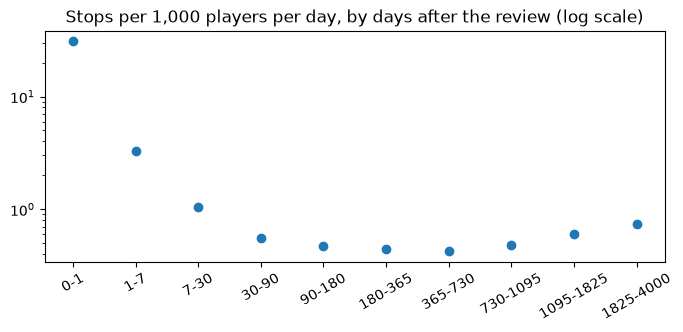

In [3]:
cuts = [0, 1, 7, 30, 90, 180, 365, 730, 1095, 1825, 4000]
rows = []
for a, b in zip(cuts[:-1], cuts[1:]):
    w = rest[rest["T"] > a]                                     # still watched when the period starts
    days_in = (w["T"].clip(upper=b) - a).sum()
    stops = int(((w["T"] < b) & (w["event"] == 1)).sum())
    rows.append({"from day": a, "to day": b, "stops": stops, "per 1,000 per day": 1000 * stops / days_in, "risk": stops / days_in})
periods = pd.DataFrame(rows)
print(periods[["from day", "to day", "stops", "per 1,000 per day"]].round(2).to_string(index=False))
print(f"first day: {periods['per 1,000 per day'][0]:.1f} stops per 1,000 players per day")

plt.figure(figsize=(8, 3))
plt.plot([f"{a}-{b}" for a, b in zip(cuts[:-1], cuts[1:])], periods["per 1,000 per day"], "o")
plt.yscale("log")
plt.xticks(rotation=30)
plt.title("Stops per 1,000 players per day, by days after the review (log scale)")
plt.show()

In [4]:
left, gone = d[d["group"] == "left"], d[d["group"] == "already gone"]
print(f"first day stops: {(left['T'] < 1).sum():,}, within an hour after the review: {(left['T'] < 1 / 24).sum():,}")
print(f"already gone whose last session was in the hour before the review: "
      f"{((gone['start'] - gone['last_played']).dt.total_seconds() <= 3600).sum():,}")

first day stops: 6,341, within an hour after the review: 3,249
already gone whose last session was in the hour before the review: 2,934


The standard two parameter survival curves, against a separate constant risk in each period. Average miss = mean absolute gap from the real curve over days 1 to 2,500.

In [5]:
T_pos = rest["T"].clip(lower=0.0001)                 # these curves need T above zero
rows = []
for name, f in [("exponential (one churn rate)", ExponentialFitter()), ("Weibull", WeibullFitter()),
                ("log normal", LogNormalFitter()), ("log logistic", LogLogisticFitter())]:
    f.fit(T_pos, rest["event"])
    curve = (1 - gone_share) * f.survival_function_at_times(days).values
    rows.append({"curve": name, "average miss, points": 100 * np.abs(curve[1:2501] - real[1:2501]).mean(),
                 "day 90": curve[90], "1 year": curve[365], "AIC": f.AIC_})
print(pd.DataFrame(rows).round(3).to_string(index=False, formatters={"AIC": "{:,.0f}".format}))


def piecewise(edges, data, t):
    total = np.zeros(len(t))
    for a, b in zip(edges[:-1], edges[1:]):
        w = data[data["T"] > a]
        total += ((w["T"] < b) & (w["event"] == 1)).sum() / (w["T"].clip(upper=b) - a).sum() * np.clip(t - a, 0, b - a)
    return np.exp(-total)


model_2 = (1 - gone_share) * piecewise(cuts, rest, days)
loglik = (periods["stops"] * np.log(periods["risk"])).sum() - periods["stops"].sum()
print(f"ten periods: average miss {100 * np.abs(model_2[1:2501] - real[1:2501]).mean():.2f} points, AIC {2 * len(periods) - 2 * loglik:,.0f}")
for name, edges in [("5 periods", [0, 7, 90, 365, 1095, 4000]),
                    ("20 periods", [0, 1, 3, 7, 14, 30, 60, 90, 135, 180, 270, 365, 545, 730, 910, 1095, 1460, 1825, 2190, 2555, 4000])]:
    c = (1 - gone_share) * piecewise(edges, rest, days)
    print(f"{name}: day 90 {c[90]:.1%}, 1 year {c[365]:.1%}, median {days[c <= 0.5][0]:,} days")

                       curve  average miss, points  day 90  1 year       AIC
exponential (one churn rate)                 1.712   0.869   0.745 1,612,072
                     Weibull                 5.479   0.801   0.672 1,576,691
                  log normal                 9.873   0.754   0.640 1,618,207
                log logistic                 7.370   0.801   0.672 1,590,285
ten periods: average miss 0.16 points, AIC 1,561,185
5 periods: day 90 82.0%, 1 year 72.4%, median 1,166 days
20 periods: day 90 82.0%, 1 year 72.5%, median 1,167 days


In [6]:
steady = periods[periods["from day"].between(90, 730)]          # day 90 to year 3
print(f"first day risk: {periods['per 1,000 per day'][0]:.2f}; day 90 to year 3: "
      f"{steady['per 1,000 per day'].min():.2f} to {steady['per 1,000 per day'].max():.2f}, "
      f"pooled {1000 * steady['stops'].sum() / (steady['stops'] / steady['risk']).sum():.2f}, "
      f"so about {periods['risk'][0] / (steady['stops'].sum() / (steady['stops'] / steady['risk']).sum()):.0f} times")
print(f"stops in the first week: {periods['stops'][:2].sum():,}; between day 90 and year 1: {periods['stops'][4:6].sum():,}")
print(f"retained days in the next 365 (restricted mean): real {real[:365].sum():.0f}, one churn rate {model_1[:365].sum():.0f}, "
      f"ten periods {model_2[:365].sum():.0f}")

first day risk: 30.95; day 90 to year 3: 0.42 to 0.48, pooled 0.45, so about 69 times
stops in the first week: 10,331; between day 90 and year 1: 20,032
retained days in the next 365 (restricted mean): real 288, one churn rate 302, ten periods 288


## 2. The pattern shifted in recent years
Each stage's risk in each calendar year (stops per 1,000 per day; blank where under 300,000 days were watched).

                  2018  2019  2020  2021  2022  2023  2024  2025
day 30 to 90      0.89  0.50  0.50  0.65  0.45  0.47  0.56  0.70
day 90 to 365     0.56  0.45  0.41  0.51  0.49  0.33  0.46  0.59
day 365 to 730     NaN  0.36  0.41  0.38  0.50  0.36  0.39  0.61
day 730 to 1095    NaN   NaN  0.45  0.37  0.40  0.44  0.48  0.59
day 1095 to 1825   NaN   NaN   NaN  0.46  0.47  0.41  0.57  0.88
day 1825 to 4000   NaN   NaN   NaN   NaN   NaN  0.51  0.60  0.95
2023 across its stages: 0.33 to 0.51


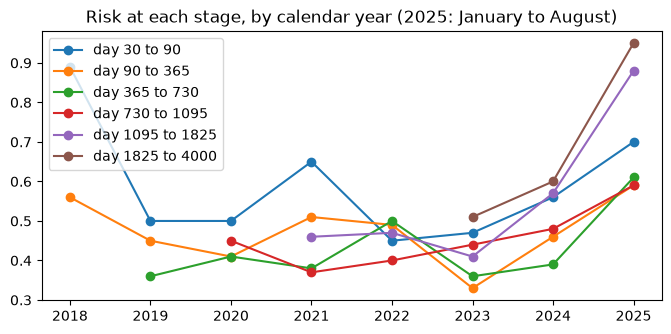

In [7]:
stop_date = rest["start"] + pd.to_timedelta(rest["T"], unit="D")
STAGES = [(30, 90), (90, 365), (365, 730), (730, 1095), (1095, 1825), (1825, 4000)]


def stage_risk(a, b, y0, y1):
    enters = rest["start"] + pd.Timedelta(days=a)
    leaves = rest["start"] + pd.to_timedelta(rest["T"].clip(upper=b), unit="D")
    stopped = (rest["event"] == 1) & (rest["T"] >= a) & (rest["T"] < b) & (stop_date >= y0) & (stop_date < y1)
    days_in = (leaves.clip(upper=y1) - enters.clip(lower=y0)).dt.total_seconds().clip(lower=0).sum() / DAY
    return 1000 * stopped.sum() / days_in, days_in


table = {}
for a, b in STAGES:
    row = {}
    for y in range(2018, 2026):
        v, n = stage_risk(a, b, pd.Timestamp(f"{y}-01-01"), min(pd.Timestamp(f"{y + 1}-01-01"), END))
        row[y] = round(v, 2) if n > 300000 else np.nan
    table[f"day {a} to {b}"] = row
calendar = pd.DataFrame(table).T
print(calendar.to_string())
print(f"2023 across its stages: {calendar[2023].min():.2f} to {calendar[2023].max():.2f}")

calendar.T.plot(figsize=(8, 3.5), marker="o", title="Risk at each stage, by calendar year (2025: January to August)")
plt.show()

Recent stops have had the least time to be confirmed. Check: count only stops followed by at least 540 days (about 18 months) without play before the download.

In [8]:
cut = DOWNLOAD - pd.Timedelta(days=540)
print(f"only stops up to {cut:%d %b %Y} have 540 days of silence before the download, so compare 1 January to 6 March of each year")
check = {}
for a, b in STAGES:
    check[f"day {a} to {b}"] = {y: round(stage_risk(a, b, pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-03-06"))[0], 2) for y in (2024, 2025)}
print(pd.DataFrame(check).T.to_string())
for y in (2024, 2025):                                  # every counted stop is a last session with no play after it
    w = (rest["event"] == 1) & (stop_date >= f"{y}-01-01") & (stop_date < f"{y}-03-06")
    silence = (DOWNLOAD - rest.loc[w, "last_played"]).dt.days
    print(f"{y}: {w.sum():,} stops from 1 January to 6 March, each followed by {silence.min()} to {silence.max()} days "
          f"({silence.min() / 30.44:.1f} to {silence.max() / 30.44:.1f} months) without play")

only stops up to 06 Mar 2025 have 540 days of silence before the download, so compare 1 January to 6 March of each year


                  2024  2025
day 30 to 90      0.47  0.61
day 90 to 365     0.47  0.53
day 365 to 730    0.37  0.54
day 730 to 1095   0.53  0.55
day 1095 to 1825  0.53  0.81
day 1825 to 4000  0.57  0.96
2024: 3,470 stops from 1 January to 6 March, each followed by 905 to 970 days (29.7 to 31.9 months) without play
2025: 5,032 stops from 1 January to 6 March, each followed by 540 to 604 days (17.7 to 19.8 months) without play


## 3. Playtime, thumbs and language, together
A Cox model: hazard ratios are multipliers on the daily risk, with the baseline over time left free.

In [9]:
p = d[d["author_playtime_at_review"].notna()].copy()
BANDS = ["under 1 h", "1 to 20 h", "20 to 100 h", "100 to 1,000 h", "over 1,000 h"]
p["hours"] = p["author_playtime_at_review"] / 60
p["log_hours"] = np.log10(p["hours"])
p["band"] = pd.cut(p["hours"], [0, 1, 20, 100, 1000, np.inf], labels=BANDS, right=False)
p["thumbs_down"] = (p["voted_up"] == False).astype(int)
p["not_english"] = (p["language"] != "english").astype(int)
p["protest_week"] = ((p["start"] >= "2022-07-25") & (p["start"] < "2022-08-01")).astype(int)
p["already_gone"] = (p["group"] == "already gone").astype(int)
for b in BANDS[1:]:
    p[b] = (p["band"] == b).astype(int)
live = p[p["already_gone"] == 0]
print(f"with a recorded playtime: {len(p):,}; still playing at time zero: {len(live):,} ({len(rest) - len(live)} with no playtime left out)")

inputs = BANDS[1:] + ["thumbs_down", "not_english"]
m3 = CoxPHFitter().fit(live[["T", "event"] + inputs], "T", "event")
hr = m3.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]]
print(hr.round(3).to_string())
print(f"over 1,000 hours: about 1/{1 / m3.hazard_ratios_['over 1,000 h']:.0f} of the daily risk of under 1 hour")

m3_periods = CoxPHFitter(baseline_estimation_method="piecewise", breakpoints=cuts[1:-1]).fit(
    live[["T", "event"] + inputs], "T", "event")
diff = (np.exp(m3_periods.params_["beta_"].drop("Intercept")) - m3.hazard_ratios_).abs().max()
print(f"the ten periods as the baseline instead: multipliers within {diff:.3f}")

with a recorded playtime: 229,805; still playing at time zero: 210,012 (69 with no playtime left out)


                exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                          
1 to 20 h           0.815                0.794                0.835
20 to 100 h         0.495                0.482                0.509
100 to 1,000 h      0.246                0.239                0.254
over 1,000 h        0.089                0.085                0.094
thumbs_down         1.139                1.120                1.159
not_english         1.151                1.136                1.167
over 1,000 hours: about 1/11 of the daily risk of under 1 hour


the ten periods as the baseline instead: multipliers within 0.003


In [10]:
inputs = BANDS[1:] + ["thumbs_down", "not_english", "protest_week"]
m3b = CoxPHFitter().fit(live[["T", "event"] + inputs], "T", "event")
td, pw = m3b.hazard_ratios_["thumbs_down"], m3b.hazard_ratios_["protest_week"]
print(f"protest week set apart: thumbs down {td:.2f}, protest week {pw:.2f}, a protest thumbs down {td * pw:.2f}")

protest week set apart: thumbs down 1.24, protest week 0.73, a protest thumbs down 0.91


Is each multiplier the same on every day? Refit the model in six windows after the review.

covariate        1 to 20 h  20 to 100 h  100 to 1,000 h  over 1,000 h  thumbs_down  not_english  protest_week
day 0 to 1          0.4605       0.1293          0.0267        0.0076       1.3963       1.4328        0.2719
day 1 to 7          0.6560       0.2087          0.0572        0.0194       1.1502       1.2208        0.3435
day 7 to 90         0.6350       0.3063          0.1211        0.0415       1.1233       1.1055        0.4675
day 90 to 365       0.8388       0.4749          0.2136        0.0776       1.1963       1.1179        0.5621
day 365 to 730      0.9829       0.6577          0.3306        0.1115       1.2510       1.1243        0.7408
day 730 to 4000     1.0504       0.8295          0.4817        0.1937       1.3301       1.1121        1.0052
under 1 h against over 1,000 h: 132 times on the first day, 5.2 times after year two (one multiplier: 0.09)
thumbs down and language across the windows: 1.11 to 1.43; protest week 0.27 on the first day, 1.01 after year two


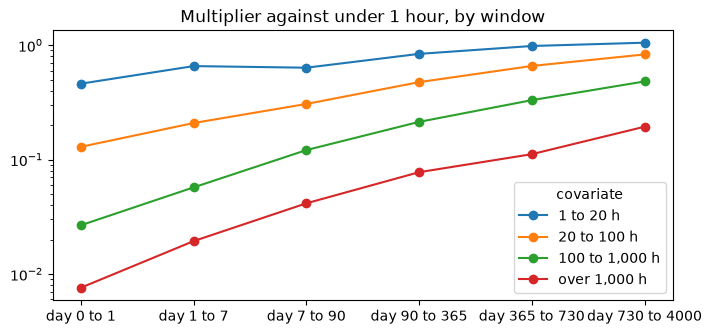

In [11]:
WINDOWS = [(0, 1), (1, 7), (7, 90), (90, 365), (365, 730), (730, 4000)]
rows = []
for a, b in WINDOWS:
    w = live[live["T"] > a].copy()
    w["event"] = ((w["T"] < b) & (w["event"] == 1)).astype(int)
    w["T"] = w["T"].clip(upper=b) - a
    row = CoxPHFitter().fit(w[["T", "event"] + inputs], "T", "event").hazard_ratios_.round(4)
    row.name = f"day {a} to {b}"
    rows.append(row)
by_window = pd.DataFrame(rows)
print(by_window.to_string())

top = by_window["over 1,000 h"]
print(f"under 1 h against over 1,000 h: {1 / top.iloc[0]:.0f} times on the first day, {1 / top.iloc[-1]:.1f} times after year two "
      f"(one multiplier: {m3b.hazard_ratios_['over 1,000 h']:.2f})")
other = by_window[["thumbs_down", "not_english"]]
print(f"thumbs down and language across the windows: {other.values.min():.2f} to {other.values.max():.2f}; "
      f"protest week {by_window['protest_week'].iloc[0]:.2f} on the first day, {by_window['protest_week'].iloc[-1]:.2f} after year two")

by_window[BANDS[1:]].plot(figsize=(8, 3.5), marker="o", logy=True, title="Multiplier against under 1 hour, by window")
plt.show()

In [12]:
others = "thumbs_down + not_english + protest_week"
fits = {"5 bands": m3b,
        "a straight line": CoxPHFitter().fit(live[["T", "event", "log_hours", "thumbs_down", "not_english", "protest_week"]], "T", "event",
                                             formula="log_hours + " + others),
        "a spline": CoxPHFitter().fit(live[["T", "event", "log_hours", "thumbs_down", "not_english", "protest_week"]], "T", "event",
                                      formula="bs(log_hours, df=3) + " + others)}
print(pd.DataFrame({"AIC": {k: m.AIC_partial_ for k, m in fits.items()},
                    "concordance": {k: m.concordance_index_ for k, m in fits.items()}}).round(3).to_string())

                         AIC  concordance
5 bands          2152324.673        0.682
a straight line  2153426.479        0.692
a spline         2150016.491        0.692


I handle this with one small Cox model per playtime band, a step beyond stratifying by band: each band gets its own baseline and also its own multipliers.

In [13]:
X = ["thumbs_down", "not_english", "protest_week"]
band_models, rows = {}, []
for b in BANDS:
    m = CoxPHFitter().fit(live.loc[live["band"] == b, ["T", "event"] + X], "T", "event")
    band_models[b] = m
    s = m.summary
    rows.append({"band": b, "people": int((live["band"] == b).sum()),
                 "thumbs down": f"{s.loc['thumbs_down', 'exp(coef)']:.2f} ({s.loc['thumbs_down', 'exp(coef) lower 95%']:.2f} to {s.loc['thumbs_down', 'exp(coef) upper 95%']:.2f})",
                 "not English": round(s.loc["not_english", "exp(coef)"], 2), "protest week": round(s.loc["protest_week", "exp(coef)"], 2)})
print(pd.DataFrame(rows).to_string(index=False))

for b in ("1 to 20 h", "over 1,000 h"):                         # a multiplier in people: more gone within a year
    s = band_models[b].predict_survival_function(pd.DataFrame({"thumbs_down": [0, 1], "not_english": 0, "protest_week": 0}), times=[365]).values[0]
    print(f"{b}: a year later {s[0]:.1%} with a thumbs up, {s[1]:.1%} with a thumbs down: {100 * (s[0] - s[1]):.1f} more in 100 gone")

          band  people         thumbs down  not English  protest week
     under 1 h    8678 1.08 (1.02 to 1.15)         1.23          0.62
     1 to 20 h   80898 1.21 (1.17 to 1.24)         1.19          0.70
   20 to 100 h   48459 1.34 (1.28 to 1.39)         1.09          0.75
100 to 1,000 h   47589 1.40 (1.33 to 1.47)         0.95          0.68
  over 1,000 h   24388 1.47 (1.32 to 1.64)         0.91          0.66
1 to 20 h: a year later 69.3% with a thumbs up, 64.2% with a thumbs down: 5.1 more in 100 gone
over 1,000 h: a year later 97.6% with a thumbs up, 96.5% with a thumbs down: 1.1 more in 100 gone


In [14]:
p["start_year"] = p["start"].dt.year
live = p[p["already_gone"] == 0]
print("thumbs down share (%) among people still playing at time zero, by start year:",
      (100 * live.groupby("start_year")["thumbs_down"].mean()).round(0).to_dict())
rows = []
for b in BANDS:
    same_year = CoxPHFitter().fit(live.loc[live["band"] == b, ["T", "event", "start_year"] + X], "T", "event", strata=["start_year"])
    a, s = band_models[b].hazard_ratios_["thumbs_down"], same_year.hazard_ratios_["thumbs_down"]
    rows.append({"band": b, "thumbs down": round(a, 3), "within the same start year": round(s, 3), "smaller by": round(a - s, 3)})
shrink = pd.DataFrame(rows).set_index("band")
print(shrink.to_string())
print(f"smaller by {shrink['smaller by'].min():.2f} to {shrink['smaller by'].max():.2f}")

thumbs down share (%) among people still playing at time zero, by start year: {2017: 8.0, 2018: 8.0, 2019: 7.0, 2020: 6.0, 2021: 8.0, 2022: 46.0, 2023: 17.0, 2024: 20.0, 2025: 25.0}


                thumbs down  within the same start year  smaller by
band                                                               
under 1 h             1.082                       1.002       0.080
1 to 20 h             1.206                       1.140       0.066
20 to 100 h           1.335                       1.244       0.092
100 to 1,000 h        1.401                       1.303       0.098
over 1,000 h          1.472                       1.407       0.065
smaller by 0.07 to 0.10


In [15]:
by_thumbs = pd.crosstab(p["band"], p["thumbs_down"], values=p["already_gone"], aggfunc="mean")
by_thumbs.columns = ["thumbs up", "thumbs down"]
by_thumbs["times as likely"] = by_thumbs["thumbs down"] / by_thumbs["thumbs up"]
print("share already gone at time zero:")
print(by_thumbs.round(3).to_string())

share already gone at time zero:
                thumbs up  thumbs down  times as likely
band                                                   
under 1 h           0.345        0.514            1.492
1 to 20 h           0.085        0.287            3.381
20 to 100 h         0.024        0.114            4.682
100 to 1,000 h      0.009        0.037            4.108
over 1,000 h        0.003        0.010            3.748


## 4. Checked on held out reviewers, and on later years
Both versions predict the share still playing a year later for ten groups (band x thumbs): one multiplier per input, and one model per band.

                       actual  one multiplier  per band  95% CI half width
band           thumbs                                                     
under 1 h      up        35.8            41.7      35.4                1.3
               down      28.1            28.1      26.1                1.9
1 to 20 h      up        61.5            64.1      61.8                0.5
               down      47.0            47.3      46.1                1.1
20 to 100 h    up        81.1            78.6      81.2                0.6
               down      73.2            69.6      70.9                1.2
100 to 1,000 h up        92.1            88.8      92.4                0.4
               down      89.3            85.6      88.6                0.7
over 1,000 h   up        96.9            96.0      97.6                0.4
               down      96.5            95.0      96.3                0.5
everyone a year later: actual 72.5%, per band model 72.7%


one multiplier  average miss 2.5 points, largest 5.9, concordance 0.714


per band        average miss 0.8 points, largest 2.3, concordance 0.714
sampling uncertainty of the ten groups: 95% CI half widths 0.4 to 1.9 points
20 to 100 h, thumbs down, all weeks: per band model misses by -2.3 points
20 to 100 h, thumbs down, outside the protest week: per band model misses by -0.1 points


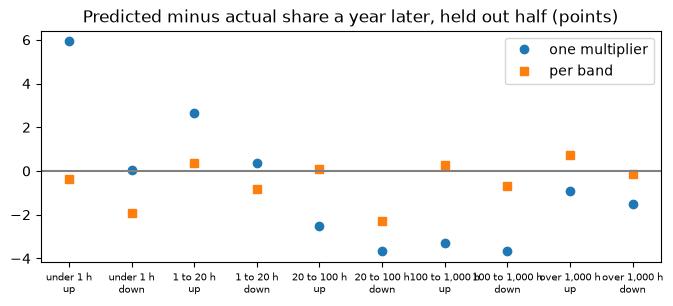

In [16]:
ALL = BANDS[1:] + X


def two_part(train, test):
    """Share already gone from the 20 training groups, times each version's survival at day 365."""
    test = test.copy()
    train_live = train[train["already_gone"] == 0]
    shares = train.groupby(["band", "thumbs_down", "not_english"], observed=True)["already_gone"].mean()
    gone_part = 1 - shares.loc[list(zip(test["band"], test["thumbs_down"], test["not_english"]))].values
    test["per band"] = 0.0
    for b in BANDS:
        m = CoxPHFitter().fit(train_live.loc[train_live["band"] == b, ["T", "event"] + X], "T", "event")
        inb = (test["band"] == b).values
        test.loc[inb, "per band"] = m.predict_survival_function(test.loc[inb, X], times=[365]).values[0]
    m = CoxPHFitter().fit(train_live[["T", "event"] + ALL], "T", "event")
    test["one multiplier"] = m.predict_survival_function(test[ALL], times=[365]).values[0]
    test[["per band", "one multiplier"]] = test[["per band", "one multiplier"]].mul(gone_part, axis=0)
    rows = []
    for b in BANDS:
        for down in (0, 1):
            g = test[(test["band"] == b) & (test["thumbs_down"] == down)]
            k = KaplanMeierFitter().fit(g["T"], g["event"])
            ci = k.confidence_interval_survival_function_
            rows.append({"band": b, "thumbs": "down" if down else "up", "actual": k.predict(365),
                         "one multiplier": g["one multiplier"].mean(), "per band": g["per band"].mean(),
                         "95% CI half width": float(ci[ci.index <= 365].iloc[-1].diff().iloc[-1]) / 2})
    return test, pd.DataFrame(rows)


def report(test, groups):
    print(f"everyone a year later: actual {KaplanMeierFitter().fit(test['T'], test['event']).predict(365):.1%}, "
          f"per band model {test['per band'].mean():.1%}")
    for v in ("one multiplier", "per band"):
        miss = 100 * (groups[v] - groups["actual"]).abs()
        print(f"{v:<15} average miss {miss.mean():.1f} points, largest {miss.max():.1f}, "
              f"concordance {concordance_index(test['T'], test[v], test['event']):.3f}")


first_half = np.random.default_rng(1).random(len(p)) < 0.5
test_half, groups = two_part(p[first_half], p[~first_half])
print((100 * groups.set_index(["band", "thumbs"])).round(1).to_string())
report(test_half, groups)
print(f"sampling uncertainty of the ten groups: 95% CI half widths {100 * groups['95% CI half width'].min():.1f} to {100 * groups['95% CI half width'].max():.1f} points")

g = test_half[(test_half["band"] == "20 to 100 h") & (test_half["thumbs_down"] == 1)]
for name, mask in (("all weeks", g["protest_week"] >= 0), ("outside the protest week", g["protest_week"] == 0)):
    act = KaplanMeierFitter().fit(g.loc[mask, "T"], g.loc[mask, "event"]).predict(365)
    print(f"20 to 100 h, thumbs down, {name}: per band model misses by {100 * (g.loc[mask, 'per band'].mean() - act):+.1f} points")

plt.figure(figsize=(8, 3))
for v, mk in (("one multiplier", "o"), ("per band", "s")):
    plt.plot(range(10), 100 * (groups[v] - groups["actual"]), mk, label=v)
plt.axhline(0, color="grey")
plt.xticks(range(10), [f"{b}\n{t}" for b, t in zip(groups["band"], groups["thumbs"])], fontsize=7)
plt.title("Predicted minus actual share a year later, held out half (points)")
plt.legend()
plt.show()

Cohort holdout: fit on reviewers whose clock started in 2019 to 2022, predict those from 2023 and 2024. Not a clean forecast: both are followed through some of the same calendar years.

In [17]:
year = p["start_year"]
old, new = p[year.between(2019, 2022)], p[year.between(2023, 2024)]
test_new, groups_new = two_part(old, new)
report(test_new, groups_new)

old_all = d[d["start"].dt.year.between(2019, 2022)]               # the period model with no inputs needs no playtime
no_inputs = (1 - (old_all["group"] == "already gone").mean()) * piecewise(cuts, old_all[old_all["group"] != "already gone"], np.arange(366))
print(f"no inputs, ten periods: predicted {no_inputs[365]:.1%} a year later")

everyone a year later: actual 73.1%, per band model 77.4%
one multiplier  average miss 4.2 points, largest 15.0, concordance 0.740
per band        average miss 4.1 points, largest 8.8, concordance 0.740


no inputs, ten periods: predicted 74.4% a year later


In [18]:
newer = {"2019 to 2022": old, "2023": p[year == 2023], "2024": p[year == 2024]}
print(f"over 1,000 hours at review: 2019 to 2022 {(old['band'] == 'over 1,000 h').mean():.1%}, 2023 to 2024 {(new['band'] == 'over 1,000 h').mean():.1%}")
print(f"same, never edited reviews: 2019 to 2022 {(old.loc[~old['edited'], 'band'] == 'over 1,000 h').mean():.1%}, "
      f"2023 to 2024 {(new.loc[~new['edited'], 'band'] == 'over 1,000 h').mean():.1%}")
one_year = lambda x: KaplanMeierFitter().fit(x["T"], x["event"]).predict(365)
rows = []
for b in BANDS:
    row = {k: one_year(v[v["band"] == b]) for k, v in newer.items()}
    row["drop, never edited only"] = one_year(old[(old["band"] == b) & ~old["edited"]]) - one_year(new[(new["band"] == b) & ~new["edited"]])
    rows.append(pd.Series(row, name=b))
print((100 * pd.DataFrame(rows)).round(1).to_string())
print(f"everyone a year later: 2019 to 2022 {one_year(old):.1%}, 2023 to 2024 {one_year(new):.1%}; all years {one_year(d):.1%}; "
      f"2018 {one_year(d[d['start'].dt.year == 2018]):.1%}; 2025 {one_year(d[d['start'].dt.year == 2025]):.1%}")

over 1,000 hours at review: 2019 to 2022 9.4%, 2023 to 2024 13.4%
same, never edited reviews: 2019 to 2022 8.0%, 2023 to 2024 9.8%
                2019 to 2022  2023  2024  drop, never edited only
under 1 h               33.9  29.8  24.6                      8.1
1 to 20 h               61.9  58.1  53.1                      7.1
20 to 100 h             81.6  79.3  73.9                      5.3
100 to 1,000 h          92.5  91.6  88.4                      2.9
over 1,000 h            97.5  97.0  95.7                      1.7


everyone a year later: 2019 to 2022 74.5%, 2023 to 2024 73.1%; all years 72.5%; 2018 57.8%; 2025 70.5%


## 5. What the model implies for a typical reviewer
Expected retained days over the next 365, from the two part model (risk for reviewers outside the protest week). Retained days are the calendar days from the review to the last observed session, capped at the horizon, here 365: they measure how long people stay, not how many days they play.

                                                          already gone  retained days  if playing at the review
reviewer                                                                                                       
tried it briefly: under 1 h, thumbs down, other language         0.529            104                       221
new player: 1 to 20 h, thumbs up, English                        0.064            270                       289
new player: 1 to 20 h, thumbs down, English                      0.281            198                       275
regular: 20 to 100 h, thumbs up, English                         0.021            322                       329
heavy: over 1,000 h, thumbs up, English                          0.002            360                       360
heavy: over 1,000 h, thumbs down, English                        0.011            354                       358
new player, thumbs down against up: 72 fewer retained days; 14 among those playing at the review, so 58 

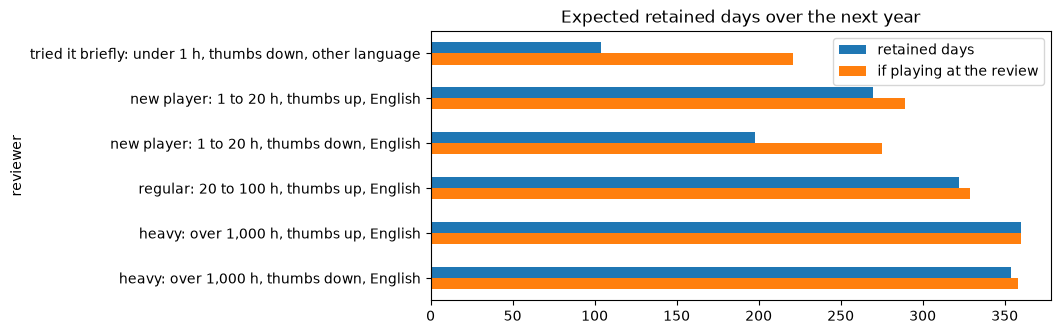

In [19]:
shares = p.groupby(["band", "thumbs_down", "not_english"], observed=True)["already_gone"].mean()
profiles = [("under 1 h", 1, 1, "tried it briefly"), ("1 to 20 h", 0, 0, "new player"), ("1 to 20 h", 1, 0, "new player"),
            ("20 to 100 h", 0, 0, "regular"), ("over 1,000 h", 0, 0, "heavy"), ("over 1,000 h", 1, 0, "heavy")]
t = np.arange(0, 366)
rows = []
for b, down, other, who in profiles:
    x = pd.DataFrame({"thumbs_down": [down], "not_english": [other], "protest_week": [0]})
    live_curve = band_models[b].predict_survival_function(x, times=t).values[:, 0]
    gone_b = shares.loc[(b, down, other)]
    rows.append({"reviewer": f"{who}: {b}, thumbs {'down' if down else 'up'}, {'other language' if other else 'English'}",
                 "already gone": round(gone_b, 3), "retained days": round(((1 - gone_b) * live_curve)[:365].sum()),
                 "if playing at the review": round(live_curve[:365].sum())})
prof = pd.DataFrame(rows).set_index("reviewer")
print(prof.to_string())
up, dn = prof.iloc[1], prof.iloc[2]
up, dn = up.astype(int), dn.astype(int)
print(f"new player, thumbs down against up: {up['retained days'] - dn['retained days']} fewer retained days; "
      f"{up['if playing at the review'] - dn['if playing at the review']} among those playing at the review, "
      f"so {up['retained days'] - dn['retained days'] - (up['if playing at the review'] - dn['if playing at the review'])} come from people who had already stopped")

prof[["retained days", "if playing at the review"]].plot.barh(figsize=(8, 3.5), title="Expected retained days over the next year")
plt.gca().invert_yaxis()
plt.show()